# EDA GoodAir
Analyse exploratoire de la source A : données météo et qualité de l'air collectées par le pipeline GoodAir.

## Imports et chargement

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

df = pd.read_csv("../data/raw/goodair_historique/fact_mesures.csv")
df["DateHeure"] = pd.to_datetime(df["DateHeure"])

# Feature dérivée : IsWeekend (seule transformation avant EDA) sera recréé dans 04_data_preparation.ipynb
df["IsWeekend"] = df["DateHeure"].dt.weekday >= 5

print("Dataset chargé.")

Dataset chargé.


## 1. Description - Dimensionnalité

In [4]:
print(f"Lignes    : {df.shape[0]}")
print(f"Colonnes  : {df.shape[1]}")
print()
print("Types de colonnes :")
print(df.dtypes)

Lignes    : 10544
Colonnes  : 16

Types de colonnes :
NomVille                  str
DateHeure      datetime64[us]
Heure                   int64
Mois                    int64
Temperature           float64
Humidite                int64
Pression                int64
VitesseVent           float64
AqiGlobal             float64
PM25                  float64
PM10                  float64
NO2                   float64
O3                    float64
MeteoStatus               str
AirStatus                 str
IsWeekend                bool
dtype: object


### Observations - Dimensionnalité
> Le dataset contient 10 544 mesures réparties sur 16 colonnes. Cela correspond à environ 3 mois de collecte horaire pour 11 villes. Les types sont cohérents : les métriques numériques sont bien en float64, les heures et mois en int64, et les statuts en string.

## 2. Description - Types de variables

In [5]:
qualitatives = ["NomVille", "MeteoStatus", "AirStatus", "IsWeekend"]
continues = [
    "Temperature",
    "Humidite",
    "Pression",
    "VitesseVent",
    "AqiGlobal",
    "PM25",
    "PM10",
    "NO2",
    "O3",
]
discretes = ["Heure", "Mois"]

print("Qualitatives :", qualitatives)
print("Continues    :", continues)
print("Discrètes    :", discretes)

Qualitatives : ['NomVille', 'MeteoStatus', 'AirStatus', 'IsWeekend']
Continues    : ['Temperature', 'Humidite', 'Pression', 'VitesseVent', 'AqiGlobal', 'PM25', 'PM10', 'NO2', 'O3']
Discrètes    : ['Heure', 'Mois']


### Observations - Types de variables
> Nos variables se répartissent en trois catégories. Les variables qualitatives (NomVille, MeteoStatus, AirStatus, IsWeekend) décrivent des caractéristiques non numériques. Les variables continues (Temperature, Humidite, Pression, VitesseVent, AqiGlobal, PM25, PM10, NO2, O3) sont nos métriques de mesure principales. Ce sont elles qui alimenteront le modèle. Les variables discrètes (Heure, Mois) capturent la dimension temporelle et seront encodées en sin/cos lors de la préparation des données.

## 3. Description - Statistiques descriptives (variables continues)

In [6]:
stats = df[continues].agg(
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        lambda x: x.quantile(0.25),
        lambda x: x.quantile(0.75),
        "max",
    ]
)
stats.index = ["count", "mean", "median", "std", "min", "Q1", "Q3", "max"]
stats.round(2)

# export des statistiques descriptives pour les variables continues
stats.to_csv("../data/processed/stats_continues_fact_mesures.csv", index=True)

### Observations - Statistiques descriptives
-  `Température`: moyenne de 17.7°C avec un minimum de -1.68°C et un maximum de 44.38°C. L'écart-type de 8°C confirme les contrastes observés entre mars (froid) et juin (canicule). Bonne variabilité pour le modèle.
- `Humidité` : centrée autour de 63%, bien répartie entre 10% et 100%. Distribution relativement symétrique (médiane 63 ≈ moyenne 63).
- `Pression` : très stable entre 996 et 1035 hPa, écart-type de seulement 6 hPa. la variable est peu dispersée mais potentiellement utile pour détecter les anticyclones.
- `VitesseVent` : moyenne de 3.2 m/s avec un maximum de 15.19 m/s. Distribution asymétrique à droite. La majorité des mesures sont en dessous de 4.3 m/s (Q3).
- `AqiGlobal` : moyenne de 39, médiane de 37. La majorité des valeurs sont en zone "Bon" (< 50). Le maximum de 434 indique des pics de pollution exceptionnels qui constituent des outliers (valeurs aberrantes) à surveiller. 18 valeurs manquantes sur 10 544. Négligeable.
- `PM25` : 860 valeurs manquantes (9684/10544), ce qui confirme que certaines stations ne mesurent pas ce polluant. Moyenne de 37 avec un maximum de 191.La distribution est très asymétrique à droite.
- `PM10` : très bien renseigné (10542/10544), moyenne basse de 16. Distribution asymétrique.
- `NO2` : quasi complet (10543/10544), moyenne de 9, maximum de 48. Bien renseigné sur l'ensemble des villes.
- `O3` : 1732 valeurs manquantes (8812/10544), taux de NULL le plus élevé après PM25. Moyenne de 29, distribution relativement symétrique (médiane 28.5 ≈ moyenne 28.8).

**Point clé :** AqiGlobal avec un max à 434 et PM10 aussi à 434 suggèrent que ces deux pics correspondent au même événement de pollution extrême - à investiguer dans les visualisations suivantes.

**Q1 et Q3 sont les 1er et 3ème quartiles, IQR = Q3 - Q1. Les outliers sont définis comme les valeurs < Q1 - 1.5*IQR ou > Q3 + 1.5*IQR.
Lorsque Q1 et Q3 sont très proches, l'IQR est petit et la détection d'outliers devient plus sensible. C'est le cas pour AqiGlobal (Q1=30, Q3=47, IQR=17) et PM10 (Q1=11, Q3=21, IQR=10). Les outliers détectés sont donc nombreux mais cohérents avec les pics de pollution observé**s.

## 4. Description - Taux de valeurs NULL par colonne

Taux de NULL (%) par colonne :
O3           16.43
PM25          8.16
AqiGlobal     0.17
PM10          0.02
NO2           0.01
dtype: float64


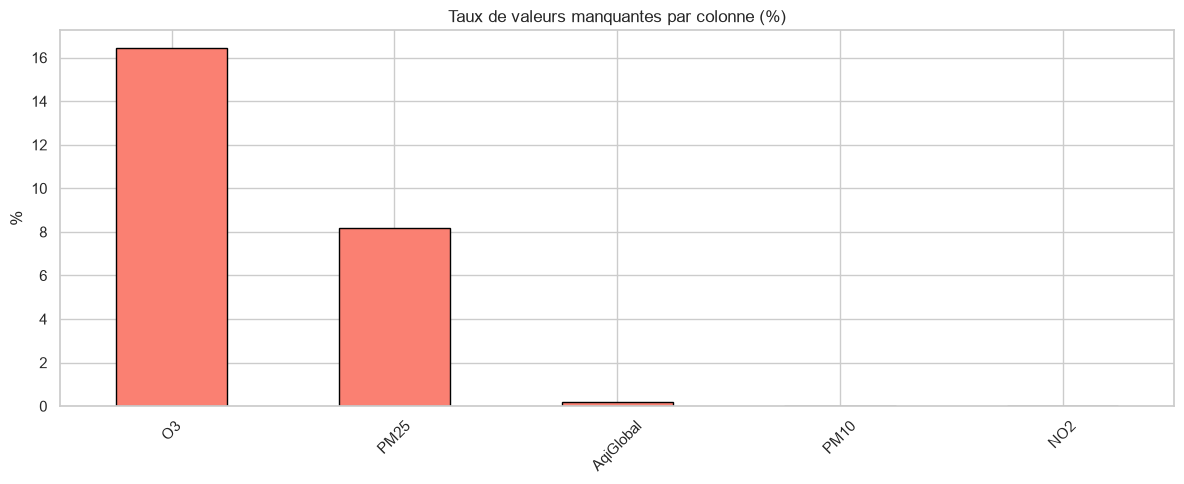

In [6]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

print("Taux de NULL (%) par colonne :")
print(null_pct.round(2))

# Visualisation
null_pct.plot(kind="bar", color="salmon", edgecolor="black")
plt.title("Taux de valeurs manquantes par colonne (%)")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations - Valeurs NULL
> Cinq colonnes présentent des valeurs manquantes. O3 est la plus impactée avec 16.43% de NULL, suivie de PM25 à 8.16%. Ces deux polluants ne sont pas mesurés par toutes les stations AQICN. C'est un comportement normal lié aux capteurs terrain, pas une erreur du pipeline.
AqiGlobal, PM10 et NO2 ont des taux négligeables (moins de 0.2%), ces quelques NULL correspondent à des pannes ponctuelles d'API.
Temperature, Humidite, Pression, VitesseVent n'ont aucun NULL. OpenWeatherMap est très fiable sur ces métriques.

## 5. Description - NULL par ville (PM25 et O3)

In [7]:
null_by_city = (
    df.groupby("NomVille")[["PM25", "O3"]]
    .apply(lambda x: x.isnull().mean() * 100)
    .round(2)
)

print("Taux de NULL PM25 et O3 par ville (%) :")
null_by_city.sort_values("PM25", ascending=False)

Taux de NULL PM25 et O3 par ville (%) :


,PM25,O3
NomVille,,
Lyon,88.84,88.84
Franconville,0.00,100.00
Bordeaux,0.00,0.00
Lille,0.00,0.00
Marseille,0.00,0.00
Nantes,0.00,0.00
Nice,0.00,0.00
Paris,0.00,0.00
Rennes,0.00,0.00


### Observations - NULL par ville
> Lyon ne mesure ni PM25 ni O3 dans 88.84% des cas, la station AQICN de Lyon ne dispose tout simplement pas de ces capteurs. C'est un comportement connu et documenté depuis le début du projet.
Franconville ne mesure jamais O3 (100% de NULL) mais fournit PM25 correctement. Sa station AQICN n'a pas de capteur ozone.
Les 9 autres villes sont quasi complètes sur PM25 et O3, avec seulement 0.83% de NULL pour Strasbourg sur O3, donc probablement des pannes ponctuelles.
Décision pour la suite : PM25 et O3 restent dans le dataset. Random Forest et XGBoost gèrent les NULL nativement. On ne supprime pas les lignes de Lyon et Franconville car leurs autres métriques (AqiGlobal, NO2, PM10) sont valides et utiles pour l'entraînement.

## 6. Description - Fréquences (variables qualitatives et discrètes)

In [8]:
print("Fréquences par NomVille")
print(df["NomVille"].value_counts())
print()
print("Fréquences par Heure")
print(df["Heure"].value_counts().sort_index())
print()
print("Fréquences par Mois")
print(df["Mois"].value_counts().sort_index())

Fréquences par NomVille
NomVille
Bordeaux        968
Lille           968
Lyon            968
Marseille       968
Nantes          968
Nice            968
Paris           968
Rennes          968
Strasbourg      968
Toulouse        968
Franconville    864
Name: count, dtype: int64

Fréquences par Heure
Heure
0     456
1     368
2     291
3     271
4     271
5     273
6     240
7     317
8     293
9     457
10    533
11    556
12    546
13    578
14    622
15    633
16    600
17    502
18    492
19    469
20    437
21    403
22    457
23    479
Name: count, dtype: int64

Fréquences par Mois
Mois
3     440
4    3339
5    3553
6    2728
7     484
Name: count, dtype: int64


### Observations - Fréquences
- `Par ville`: 10 villes ont exactement 968 mesures chacune, ce qui correspond à une collecte très régulière sur la période. Franconville a 104 mesures de moins (864). Franconville a été ajoutée légèrement plus tard dans le pipeline, ce qui explique le décalage.
- `Par heure`: la distribution est inégale, ce qui confirme les **trous temporels** liés à l'infrastructure locale (PC). Les heures de nuit (1h-6h) ont moins de mesures car le PC était probablement en veille. Les heures de journée (13h-16h) sont les mieux représentées. Ce déséquilibre justifie le choix de `TimeSeriesSplit` plutôt qu'un split aléatoire.
- `Par mois`: mars (440) et juillet (484) sont partiels car la collecte a démarré fin mars et nous sommes début juillet (le moment où nous développons la deuxième partie du projet). Avril, mai et juin sont les mois les mieux représentés avec respectivement 3339, 3553 et 2728 mesures. Le dataset couvre donc essentiellement le printemps et le début de l'été . `c'est le biais de saisonnalité assumé dans notre approche ML.`

## 7. Visualisation - Distribution (histogrammes variables continues)

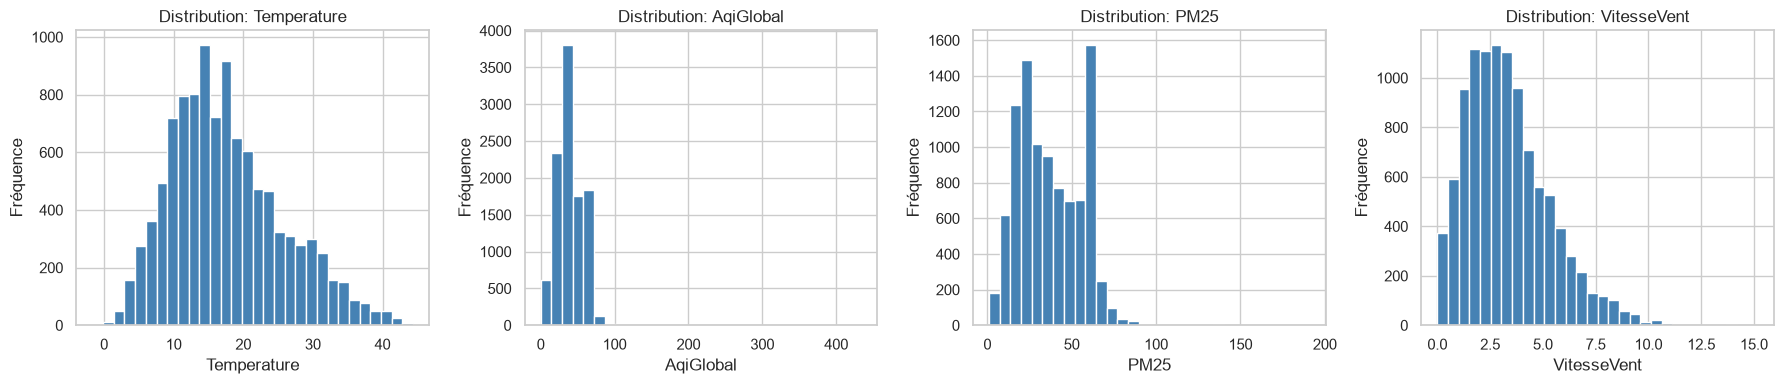

In [11]:
cols_hist = ["Temperature", "AqiGlobal", "PM25", "VitesseVent"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, cols_hist):
    df[col].dropna().plot(
        kind="hist", bins=30, ax=ax, color="steelblue", edgecolor="white"
    )
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

### Observations - Distribution
- `Température` distribution asymétrique à droite avec un pic entre 10°C et 20°C, ce qui reflète le printemps. Les valeurs au-delà de 35°C sont rares mais présentes. Ce sont les vagues de chaleur de juin. Distribution globalement cohérente avec la période mars-juillet.
- `AqiGlobal` très fortement asymétrique à droite. La grande majorité des valeurs se concentre entre 0 et 100. L'histogramme montre clairement deux groupes : un pic dominant entre 0 et 50 (air de bonne qualité) et une longue queue vers la droite qui s'étire jusqu'à 100. Les valeurs extrêmes au-delà de 200 existent dans les statistiques mais sont trop rares pour être visibles sur ce graphique. Elles seront traitées comme outliers lors de la préparation des données.
- `PM25` distribution asymétrique à droite similaire à AqiGlobal. La majorité des valeurs est entre 0 et 80, avec quelques pics au-delà de 100. Les valeurs proches de 0 à gauche correspondent probablement aux heures nocturnes ou à des conditions météo favorables (vent fort, pluie).
- `VitesseVent` distribution asymétrique à droite avec un pic entre 1 et 4 m/s. Les vents forts au-delà de 10 m/s sont rares. La majorité des mesures correspond à des conditions de vent faible à modéré. Ce qui peut expliquer pourquoi l'AQI reste souvent élevé (peu de dispersion des polluants).

## 8. Comparaison - Boxplots AqiGlobal par ville

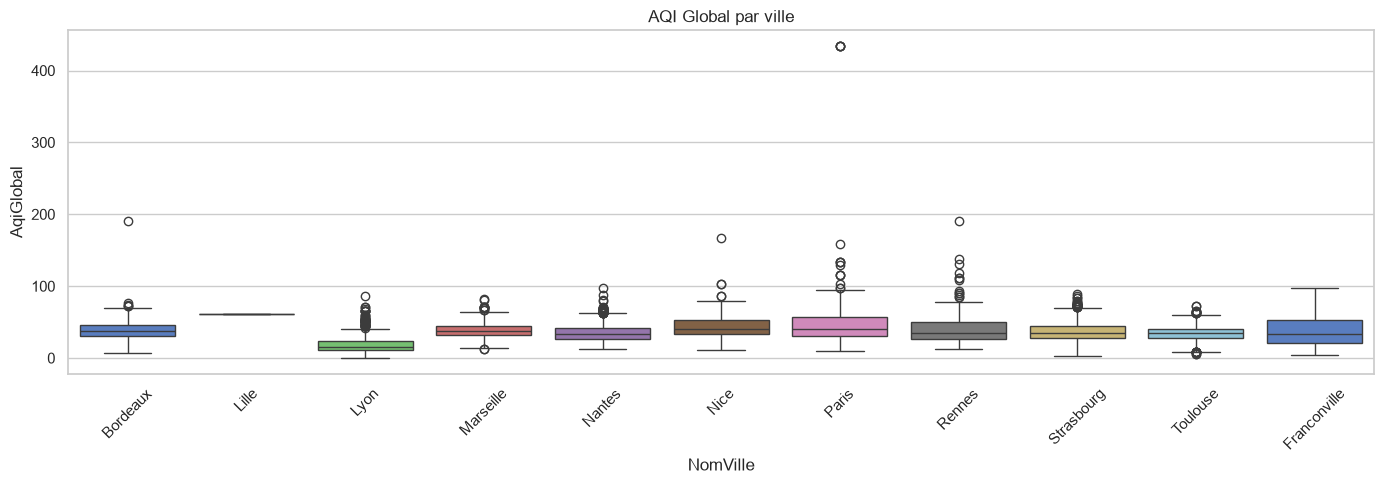

In [13]:
plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x="NomVille", y="AqiGlobal", palette="muted", hue="NomVille")
plt.title("AQI Global par ville")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations - AQI par ville
> La médiane de l'AQI est relativement homogène entre les villes, oscillant entre 20 et 50 pour la plupart. Lyon se distingue avec la médiane la plus basse (autour de 20) et une boîte très compacte. Sa station AQICN mesure peu de polluants (pas de PM25 ni O3), ce qui tire son AqiGlobal vers le bas.

> Paris est la ville avec le plus d'outliers et les valeurs les plus élevées, avec un point extrême à 434. Le pic de pollution le plus important de tout le dataset. Rennes présente aussi un outlier notable autour de 200.

> Bordeaux a un outlier isolé à ~195 mais sa boîte reste compacte et similaire aux autres villes.

> Lille présente une boîte très étroite et aplatie, peu de variance dans ses mesures AQI, signe d'une qualité de l'air stable sur la période.

> **Point clé:** les outliers visibles (cercles au-dessus des moustaches) confirment qu'une winsorisation sera nécessaire avant l'entraînement du modèle. Paris concentre la majorité de ces valeurs extrêmes.

> **NOTE IMPORTANTE:** Les boxplots sont sensibles aux outliers. La présence d'un point extrême à 434 pour Paris tire la moustache supérieure vers le haut, ce qui peut donner l'impression que la majorité des mesures parisiennes sont élevées. En réalité, la majorité des mesures parisiennes se situe entre 20 et 50, mais l'outlier extrême influence la visualisation.

## 9. Comparaison - AqiGlobal semaine vs week-end

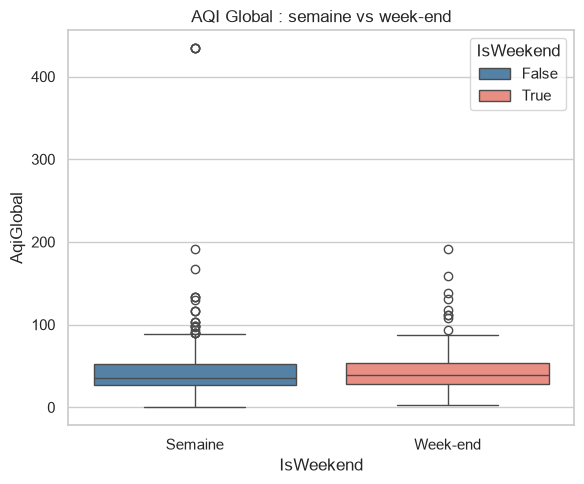

In [15]:
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=df,
    x="IsWeekend",
    y="AqiGlobal",
    palette=["steelblue", "salmon"],
    hue="IsWeekend",
)
plt.xticks([0, 1], ["Semaine", "Week-end"])
plt.title("AQI Global : semaine vs week-end")
plt.tight_layout()
plt.show()

### Observations - Semaine vs Week-end
Les deux boîtes sont quasi identiques en termes de médiane (autour de 40) et d'étendue. La qualité de l'air ne varie pas significativement entre la semaine et le week-end sur notre période de collecte. Cela peut sembler surprenant car on attendrait moins de pollution le week-end (moins de trafic).

**Deux explications possibles:** 
- nos données couvrent principalement le printemps où l'AQI est globalement bas et homogène, et l'AqiGlobal d'AQICN est un indice agrégé qui inclut des polluants non liés au trafic (ozone, particules naturelles).
- Le pic extrême à 434 apparaît côté semaine `(voir le Boxplots AqiGlobal par ville)`. Les outliers sont présents des deux côtés mais légèrement plus nombreux en semaine.
- **Conclusion:** IsWeekend sera conservée comme feature mais son pouvoir prédictif sur l'AqiGlobal semble limité sur cette période. Le test de permutation dans 04_data_preparation.ipynb confirmera ou infirmera cette observation.

## 10. Relations - Scatter plots

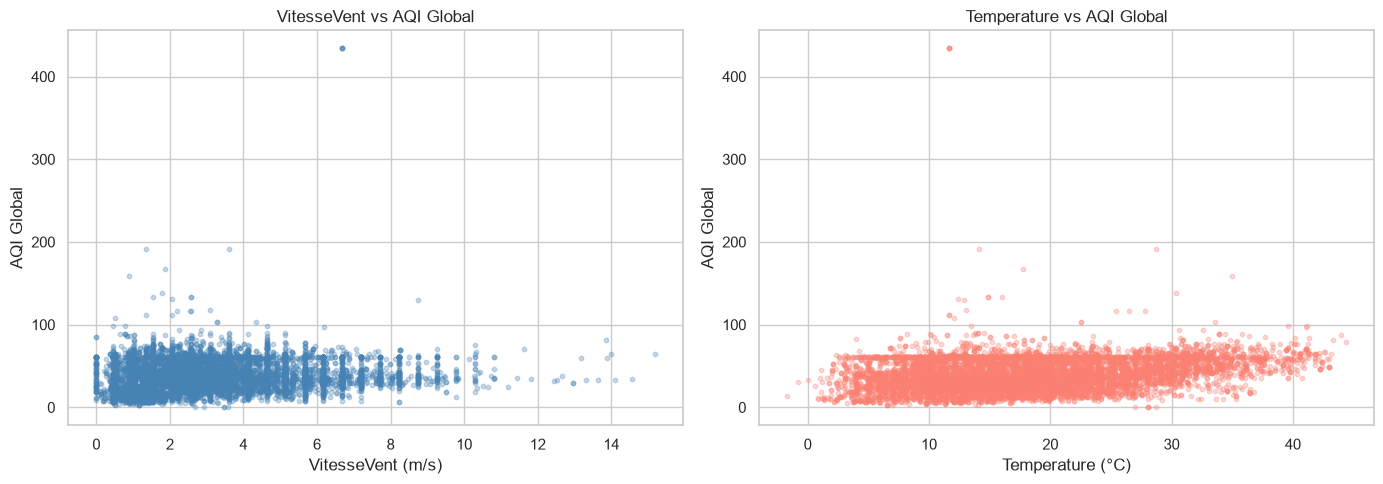

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VitesseVent vs AqiGlobal
axes[0].scatter(df["VitesseVent"], df["AqiGlobal"], alpha=0.3, color="steelblue", s=10)
axes[0].set_xlabel("VitesseVent (m/s)")
axes[0].set_ylabel("AQI Global")
axes[0].set_title("VitesseVent vs AQI Global")

# Temperature vs AqiGlobal
axes[1].scatter(df["Temperature"], df["AqiGlobal"], alpha=0.3, color="salmon", s=10)
axes[1].set_xlabel("Temperature (°C)")
axes[1].set_ylabel("AQI Global")
axes[1].set_title("Temperature vs AQI Global")

plt.tight_layout()
plt.show()

### Observations - Relations
- `VitesseVent vs AQI Global:` il n'y a pas de relation linéaire claire visible. Les points sont très dispersés sur toute la plage de vent. On remarque cependant que les valeurs d'AQI les plus élevées (au-dessus de 100) se concentrent entre 0 et 8 m/s. Les vents très forts (au-delà de 10 m/s) semblent associés à des AQI plus bas et plus stables. La relation inverse attendue (vent fort = AQI bas) existe mais elle est faible et non linéaire.
- `Temperature vs AQI Global:` **même constat :** nuage de points très dense et dispersé sans tendance linéaire évidente. L'AQI reste majoritairement entre 0 et 80 quelle que soit la température. Le pic extrême à 434 apparaît à environ 10°C. Bon ce n'est donc pas une canicule qui l'a provoqué mais probablement un autre facteur (vent, pression).
- **Conclusion générale:** ces deux variables seules n'expliquent pas bien l'AQI. La qualité de l'air est un phénomène multifactoriel autrement dit, elle est influencée par plusieurs facteurs simultanément. C'est précisément pourquoi on combine plusieurs features météo dans le modèle. La matrice de corrélation dans la cellule suivante donnera une vue plus précise des relations entre toutes les variables.

## 11. Distribution temporelle - AQI moyen par heure

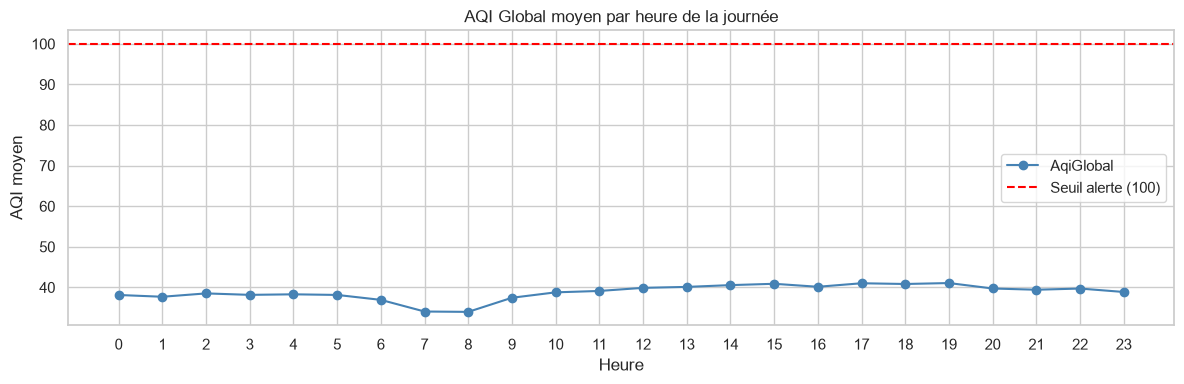

In [17]:
aqi_by_hour = df.groupby("Heure")["AqiGlobal"].mean()

plt.figure(figsize=(12, 4))
aqi_by_hour.plot(kind="line", marker="o", color="steelblue")
plt.axhline(y=100, color="red", linestyle="--", label="Seuil alerte (100)")
plt.title("AQI Global moyen par heure de la journée")
plt.xlabel("Heure")
plt.ylabel("AQI moyen")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

### Observations - Distribution temporelle
- L'AQI moyen est remarquablement stable sur toute la journée, oscillant entre 36 et 42. Il n'y a pas de pic de pollution visible à des heures spécifiques.De plus pas d'effet "heure de pointe" clairement identifiable sur les moyennes.
- Le creux le plus bas se situe entre 7h et 8h, ce qui est contre-intuitif (on attendrait un pic aux heures de trafic). Cela s'explique probablement par les trous temporels à ces heures le PC était souvent en veille tôt le matin, donc moins de mesures disponibles pour calculer la moyenne.
- L'AQI moyen reste bien en dessous du seuil d'alerte de 100 à toutes les heures - ce qui confirme que les dépassements sont des événements ponctuels et non une tendance horaire régulière.
- **Conclusion:** la variable Heure seule a peu de pouvoir prédictif sur l'AQI moyen dans nos données. Son encodage sin/cos reste pertinent pour capturer les patterns subtils que la moyenne efface, mais on ne doit pas surestimer son importance dans le modèle.

## 12. Composition - Disponibilité des APIs par ville

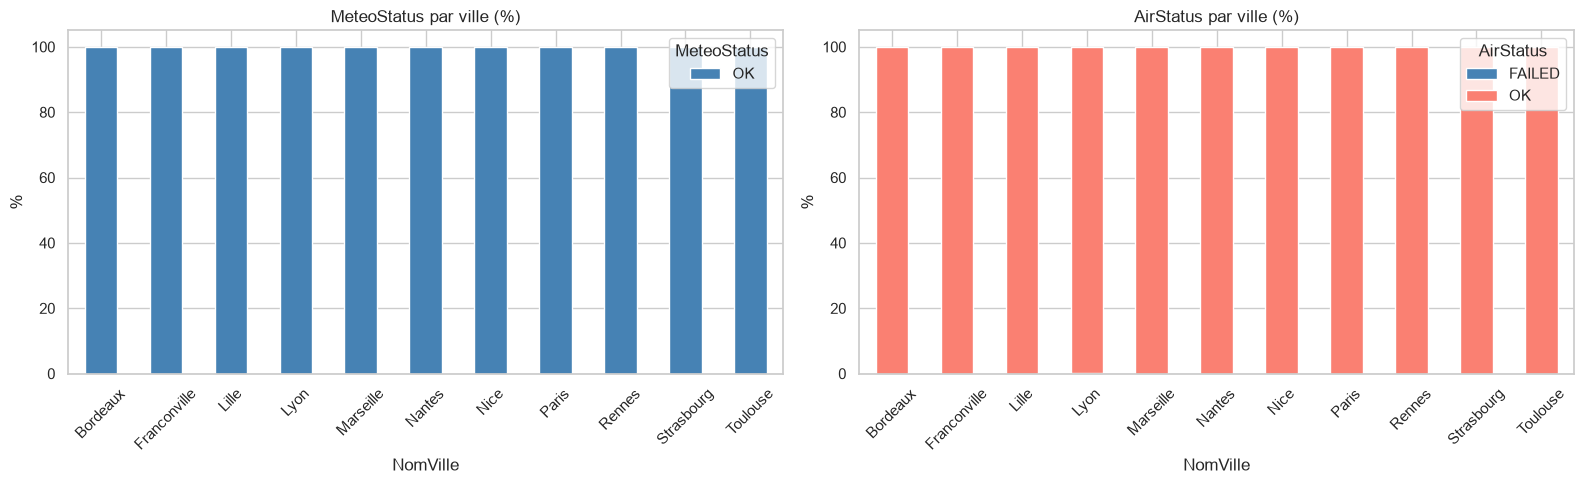

In [18]:
status_meteo = (
    df.groupby("NomVille")["MeteoStatus"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    * 100
)
status_air = (
    df.groupby("NomVille")["AirStatus"].value_counts(normalize=True).unstack().fillna(0)
    * 100
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

status_meteo.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=["steelblue", "salmon"],
    edgecolor="white",
)
axes[0].set_title("MeteoStatus par ville (%)")
axes[0].set_ylabel("%")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

status_air.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=["steelblue", "salmon"],
    edgecolor="white",
)
axes[1].set_title("AirStatus par ville (%)")
axes[1].set_ylabel("%")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### Observations - Disponibilité APIs
- **MeteoStatus** OpenWeatherMap est quasi parfaite sur toutes les villes. Seules Strasbourg et Toulouse affichent une très légère barre de FAILED visible, mais elle est infime. L'API météo est la source la plus fiable du pipeline.
  
- **AirStatus**  AQICN est également très fiable sur 9 villes avec 100% de OK. Strasbourg se distingue avec un taux de FAILED visible d'environ 20%. Cette ville a donc des problèmes récurrents de disponibilité de sa station AQICN. Toulouse présente aussi un léger taux de FAILED.
Conclusion : les deux APIs sont globalement très fiables. Strasbourg est la ville à surveiller en priorité côté AQICN. Ces résultats confirment que nos données sont de bonne qualité pour l'entraînement du modèle. Les FAILED étant rares et documentés dans les colonnes d'audit.

## 13. Matrice de corrélation (variables continues)

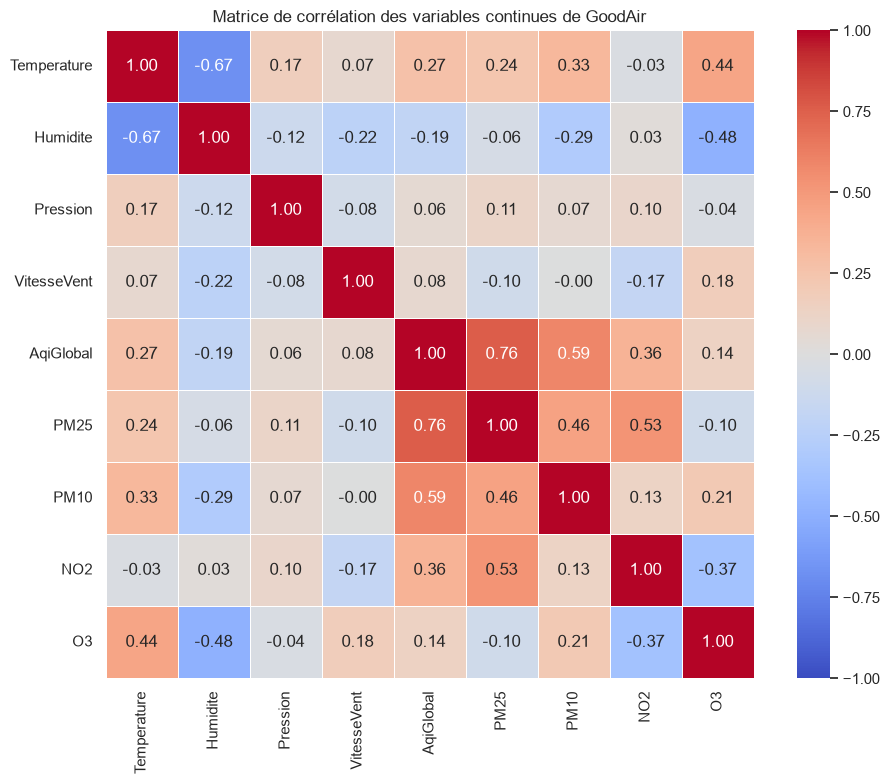

In [8]:
corr = df[continues].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title("Matrice de corrélation des variables continues de GoodAir")
plt.tight_layout()
plt.show()

### Observations - Corrélations

- `Relations avec AqiGlobal (notre variable cible Y):`
PM25 est la variable la plus corrélée avec AqiGlobal (0.76). C'est logique car les particules fines sont l'un des principaux composants de l'indice AQI. PM10 suit avec 0.59. Temperature a une corrélation modérée positive (0.27), quand il fait chaud l'AQI tend à augmenter. Humidité est légèrement négative (-0.19) et VitesseVent quasi nulle (0.08), le vent seul n'explique pas grand chose sur nos données.
- `Multicolinéarité entre features:`
- Temperature et Humidité sont fortement corrélées négativement (-0.67) quand il fait chaud l'air est moins humide. C'est une relation physique bien connue. Cette multicolinéarité n'est pas un problème pour Random Forest et XGBoost mais elle l'aurait été pour une régression linéaire.

- PM25 et PM10 sont corrélées entre elles (0.46): normal car elles mesurent des particules de tailles différentes mais de même origine.

- O3 et NO2 sont négativement corrélées (-0.37): phénomène chimique connu : quand le NO2 augmente (trafic), l'ozone diminue car il réagit avec le NO2.

- **Conclusion:** PM25 et PM10 sont les features les plus prometteuses pour prédire AqiGlobal. La température apporte aussi un signal utile. Les features Open-Meteo (direction du vent, couverture nuageuse, précipitations) complèteront ce tableau dans le notebook 03.

## 14. Synthèse générale de l'EDA GoodAir

**Points clés à retenir pour la suite :**

- 10 544 mesures propres sur 3 mois (mars-juillet 2026) pour 11 villes
- Biais de saisonnalité assumé : printemps et début d'été uniquement
- Trous temporels confirmés (heures de nuit sous-représentées) → `TimeSeriesSplit obligatoire`
- Les deux APIs sont très fiables (>95% de disponibilité), Strasbourg est la ville à surveiller

**Variables avec NULL à surveiller :**

- O3 : 16.43% de NULL globalement Franconville (100%) et Lyon (88.84%) sans capteur ozone
- PM25 : 8.16% de NULL Lyon sans capteur PM25 (88.84%)
- Ces NULL sont légitimes (capteurs absents) et seront conservés - Random Forest et XGBoost les gèrent nativement

**Outliers détectés :**

- AqiGlobal : pic extrême à 434 sur Paris, Rennes et Bordeaux au-dessus de 150, la winsorisation à 99% prévue dans 04_data_preparation.ipynb
- PM25 : valeurs jusqu'à 191. Même raisonnement que pour AqiGlobal, ces valeurs sont rares et seront traitées comme outliers
- Le pic à 434 correspond à un événement de pollution ponctuel à ~10°C (pas une canicule)

**Features prometteuses pour le modèle :**

- PM25 (corrélation 0.76 avec AqiGlobal) et PM10 (0.59) - les plus puissantes
- Temperature (0.27) - signal utile, variabilité importante sur la période
- Humidité (-0.19) et O3 (0.14) - signal faible mais à conserver
- VitesseVent (0.08) et Pression (0.06) - signal faible seuls, mais les variables complémentaires Open-Meteo (direction du vent, couverture nuageuse) pourraient renforcer ce signal dans le notebook 03